# Manual labeling for supervised classification

In [ ]:
%load_ext autoreload
%autoreload 2

import os

import numpy as np
import xarray as xr
import rioxarray as riox

from pathlib import Path
from polsarpro.io import open_netcdf_beam
from polsarpro.util import pauli_rgb

# optional import for progress bar
from dask.diagnostics import ProgressBar


# change to your data paths
# original dataset
input_alos_data = Path("/data/psp/test_files/SAN_FRANCISCO_ALOS1_slc.nc")

# output files 
output_test_dir = Path("/data/psp/")

## Open the image and make a Pauli RGB representation

In [ ]:
S = open_netcdf_beam(input_alos_data)
rgb = pauli_rgb(S)

## Convert to UINT8 and save as a Tiff file

In [ ]:
(255*rgb).astype("uint8").rio.to_raster(output_test_dir / "SF_Pauli.tif")

## Manual labeling
Recommended approach:
- Open the tif image in GIMP
- Add one layer per label, use transparent background
- Draw labels (any non-zero value) on each layer, avoid overlap bewteen different classes
- Export each layer separately as a png file

## Import hand-drawn labels

- In the following we assume that labels are png files
- We map the name of each layer to a class number
- We produce an `xarray.DataArray` that may be read by the classifier

In [ ]:
from matplotlib.image import imread
labels = {"sea": 1, "vegetation":2, "urban":3}

# create a class map with integer type from the input data size
class_map = np.zeros_like(S.hh.data.real, dtype=int)
for name in labels:

    # load class image
    im_pth = Path("/data/psp/labels") / f"{name}.png"
    # if color image we need only one channel
    im = imread(im_pth)[..., 0]
    # add with corresponding label
    class_map += labels[name] * (im > 0)

# make a data array that can be read by the classifier
da_class_map = xr.DataArray(class_map, dims=("y", "x")) 

# Optional: save array to a file using `to_netcdf`

## Apply Wishart supervised classifier

In [ ]:
from dask.diagnostics import ProgressBar
from polsarpro.classification import wishart_supervised
with ProgressBar():
    cm = wishart_supervised(S, da_class_map).compute()

[########################################] | 100% Completed | 1.37 sms
[########################################] | 100% Completed | 5.99 sms
[########################################] | 100% Completed | 19.39 s


## Visualize the results

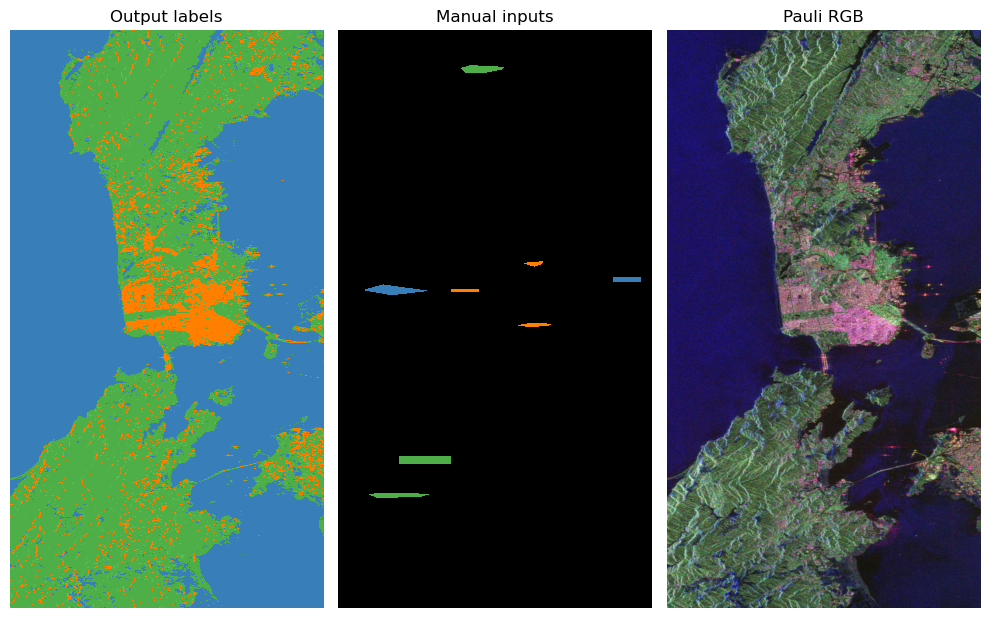

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Blue: sea/surface, green: vegetation, orange: built-up
colors = ["#387EB9", "#4EAF49", "#FF7F00"]
colors2 = ["#000000", "#387EB9", "#4EAF49", "#FF7F00"]
# Create the discrete colormap
my_cmap = ListedColormap(colors)
my_cmap2 = ListedColormap(colors2)

plt.figure(figsize=(10, 10))
plt.subplot(1,3,1)
plt.imshow(cm.wishart_supervised_class[::8], interpolation="none", cmap=my_cmap)
plt.axis("off")
plt.title("Output labels")
plt.subplot(1,3,2)
plt.imshow(class_map[::8], interpolation="none", cmap=my_cmap2)
plt.axis("off")
plt.title("Manual inputs")
plt.subplot(1,3,3)
plt.imshow(rgb.transpose("y","x","band")[::8], interpolation="bilinear")
plt.axis("off")
plt.title("Pauli RGB")
plt.tight_layout()